# Batch Normalization 
## this is a technique to improve the training of deep neural networks. It normalizes the inputs to each layer, which helps to stabilize and accelerate the training process.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# import the dataset

dataset = pd.read_csv('Churn_Modelling.csv')
dataset.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [4]:
# check the null values
dataset.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
# remove the unused features(columns)
dataset = dataset.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Geography', 'Gender'], axis=1)
dataset.head(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,42,2,0.00,1,1,1,101348.88,1
1,608,41,1,83807.86,1,0,1,112542.58,0
2,502,42,8,159660.80,3,1,0,113931.57,1


In [6]:
# input and output features

input_data = dataset.iloc[:, :-1]
output_data = dataset.iloc[:, -1]

In [7]:
# scale the input data

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

In [8]:
input_data = pd.DataFrame(ss.fit_transform(input_data), columns=input_data.columns)
input_data.head(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534
2,-1.536794,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687


In [9]:
# train test split the data

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(input_data, output_data, test_size=0.2, random_state=42)

In [25]:
import tensorflow as tf
from keras.layers import Dense, BatchNormalization
from keras.models import Sequential
from keras.regularizers import L2
from keras.callbacks import EarlyStopping

In [11]:
ann = Sequential()

In [27]:
# create the hidden layers, taking the 6 layers because input_data.shape has 8 features so we take less then 8
ann.add(Dense(units=6, input_dim=8, activation='relu', kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization())
ann.add(Dense(units=4, activation='relu'))  # you could use regularization here too
ann.add(BatchNormalization())
ann.add(Dense(units=2, activation='relu'))  # you could use regularization here too
ann.add(BatchNormalization())
ann.add(Dense(units=1, activation='sigmoid'))  # output layer

d:\anaconda3\envs\tf_310\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
# compile the model
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [29]:

ann.fit(x_train, y_train, batch_size=100, epochs=50, validation_data=(x_test, y_test), callbacks= EarlyStopping()) 

Epoch 1/50


80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7942 - loss: 0.7015 - val_accuracy: 0.8035 - val_loss: 0.6545
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7911 - loss: 0.6431 - val_accuracy: 0.8035 - val_loss: 0.5992
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7977 - loss: 0.5905 - val_accuracy: 0.8035 - val_loss: 0.5566
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7960 - loss: 0.5538 - val_accuracy: 0.8035 - val_loss: 0.5284
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8039 - loss: 0.5236 - val_accuracy: 0.8035 - val_loss: 0.5126
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7922 - loss: 0.5223 - val_accuracy: 0.8035 - val_loss: 0.5044
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7935 - loss: 0.5151 - val_accuracy: 0.8035 - val_loss: 0.5004
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7946 - loss: 0.5111 - val_accuracy: 0.8035 - val_loss: 0.4985
Ep

In [30]:
train_accuracy = ann.history.history["accuracy"]
test_accuracy = ann.history.history["val_accuracy"]

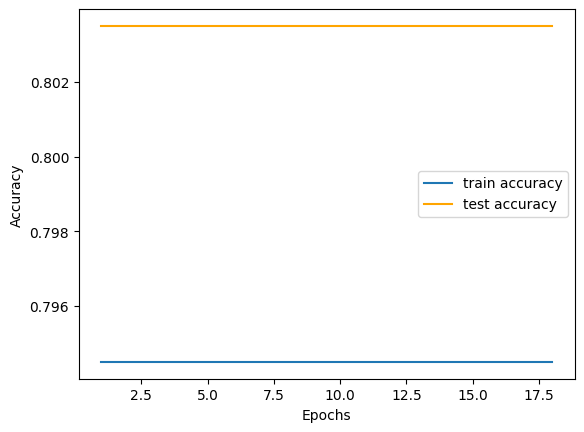

In [32]:
plt.plot([i for i in range(1, 19)], train_accuracy, label='train accuracy')
plt.plot([i for i in range(1, 19)], test_accuracy, label='test accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()